# Generalized Linear Model

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from group_lasso import GroupLasso
import warnings
from sklearn.preprocessing import StandardScaler
import gc

warnings.filterwarnings("ignore")

### 1. Configuration

In [ ]:
PATH = "C:/Users/Beau/Dropbox/Mijn pc (LAPTOP-NFBRGK0B)/Downloads/gkx2020_panel.parquet"
TARGET = "ret_excess"
LAMBDA_GRID = [1e-4, 1e-3, 1e-2, 1e-1]
VALIDATION_WINDOW_YEARS = 12
START_TEST_YEAR = 1987
END_TEST_YEAR = 2021

### 2. Data Loading

In [ ]:
print("Initializing lazy dataset...")

# (1) Lazy loading + (2) year kolom toevoegen
df_lazy = (
    pl.scan_parquet(PATH)
    .with_columns([
        pl.col(pl.NUMERIC_DTYPES).fill_null(0),
        pl.col("date").dt.year().alias("year")
    ])
)

# Feature columns bepalen (1x kleine collect)
df_sample = df_lazy.select(pl.all()).limit(1).collect()
feature_cols = [c for c in df_sample.columns if c not in ["date", "permno", "me", TARGET, "year"]]

print(f"Total features: {len(feature_cols)}")

Initializing lazy dataset...
Total features: 13


### 3. Helper Functions

In [4]:
#  Float32 casting (blijft belangrijk)
def cast_float32(df):
    return df.select([
        pl.col(c).cast(pl.Float32) if df[c].dtype == pl.Float64 else pl.col(c)
        for c in df.columns
    ])

def r2_oos(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum(y_true**2)

#  (5) Snellere spline functie (vectorized)
def get_gkx_spline_k3(X):
    return np.hstack([
        np.ones((X.shape[0], 1), dtype=np.float32),
        X,
        np.maximum(0, X) ** 2
    ])

def compute_vi_r2_reduction(model, X_sample, y_sample, feature_names):
    y_pred_base = model.predict(X_sample).flatten()
    r2_base = r2_oos(y_sample, y_pred_base)
    vi = {}

    for i, col in enumerate(feature_names):
        X_mutated = X_sample.copy()
        X_mutated[:, (i * 2) + 1 : (i * 2) + 3] = 0
        r2_mutated = r2_oos(y_sample, model.predict(X_mutated).flatten())
        vi[col] = max(0, r2_base - r2_mutated)

    return pd.Series(vi)

def plot_model_selection_over_time(years, counts):
    plt.figure(figsize=(10, 5))
    plt.plot(years, counts, linestyle='-', linewidth=2)
    plt.title("GLM + H")
    plt.ylabel("# of Char.")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, len(feature_cols) + 1)
    plt.show()

### 4. Data Preperation

In [ ]:
groups = np.array([0] + [i + 1 for i in range(len(feature_cols)) for _ in range(2)])

all_preds, all_actuals, all_years = [], [], []
all_test_dates, all_test_me, all_test_permno, all_test_exchcd = [], [], [], []
all_test_best_lam, all_test_active_features = [], []
features_selected_count = []


### 5. Recursive Estimation Loop

In [ ]:
print("Starting recursive estimation loop...")

for year in range(START_TEST_YEAR, END_TEST_YEAR + 1):
    val_start_year = year - VALIDATION_WINDOW_YEARS

    #  (1) Lazy filtering per subset
    train_df = cast_float32(
        df_lazy.filter(pl.col("year") < val_start_year).collect()
    )
    valid_df = cast_float32(
        df_lazy.filter((pl.col("year") >= val_start_year) & (pl.col("year") < year)).collect()
    )
    test_df = cast_float32(
        df_lazy.filter(pl.col("year") == year).collect()
    )

    if test_df.height == 0:
        continue

    #  (3) to_numpy zonder kopie
    X_train_raw = train_df.select(feature_cols).to_numpy()
    X_valid_raw = valid_df.select(feature_cols).to_numpy()
    X_test_raw  = test_df.select(feature_cols).to_numpy()

    y_train = train_df[TARGET].to_numpy()
    y_valid = valid_df[TARGET].to_numpy()
    y_test  = test_df[TARGET].to_numpy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)   
    X_valid_scaled = scaler.transform(X_valid_raw).astype(np.float32)       
    X_test_scaled  = scaler.transform(X_test_raw).astype(np.float32)        

    X_train_spline = get_gkx_spline_k3(X_train_scaled)
    X_valid_spline = get_gkx_spline_k3(X_valid_scaled)
    X_test_spline  = get_gkx_spline_k3(X_test_scaled)

    # Hyperparameter tuning
    best_lam, best_mse = 1e-4, np.inf

    for lam in LAMBDA_GRID:
        model = GroupLasso(groups=groups, group_reg=lam, tol=5e-2, random_state=2026)
        model.fit(X_train_spline, y_train.reshape(-1, 1))

        preds = model.predict(X_valid_spline).flatten()
        mse = np.mean((y_valid - preds) ** 2)

        if mse < best_mse:
            best_mse, best_lam = mse, lam

        del model
        gc.collect()

    # Final fit
    X_final_train = np.vstack([X_train_spline, X_valid_spline])
    y_final_train = np.concatenate([y_train, y_valid])

    final_model = GroupLasso(groups=groups, group_reg=best_lam, tol=1e-2, random_state=2026)
    final_model.fit(X_final_train, y_final_train.reshape(-1, 1))

    # Sparsity
    coefs = final_model.coef_.flatten()[1:]
    active = sum(
        1 for i in range(len(feature_cols))
        if np.linalg.norm(coefs[i*2:i*2+2]) > 1e-8
    )
    features_selected_count.append(active)

    # Predictions
    y_pred = final_model.predict(X_test_spline).flatten()

    all_preds.extend(y_pred)
    all_actuals.extend(y_test)
    all_years.append(year)

    all_test_dates.extend(test_df["date"].to_numpy())
    all_test_me.extend(test_df["me"].to_numpy())
    all_test_permno.extend(test_df["permno"].to_numpy())
    if "exchcd" in test_df.columns:
        all_test_exchcd.extend(test_df["exchcd"].to_numpy())
    else:
        all_test_exchcd.extend([np.nan] * test_df.height)
    all_test_best_lam.extend([best_lam] * test_df.height)
    all_test_active_features.extend([active] * test_df.height)

    print(f"Year {year} complete. R2: {r2_oos(y_test, y_pred):.4%}")

    X_test_spline_last = X_test_spline
    y_test_last = y_test

    del train_df, valid_df, test_df
    del X_train_raw, X_valid_raw, X_test_raw
    del X_train_spline, X_valid_spline, X_test_spline
    del X_final_train
    gc.collect()


### 6. Visualizations


Calculating Variable Importance...


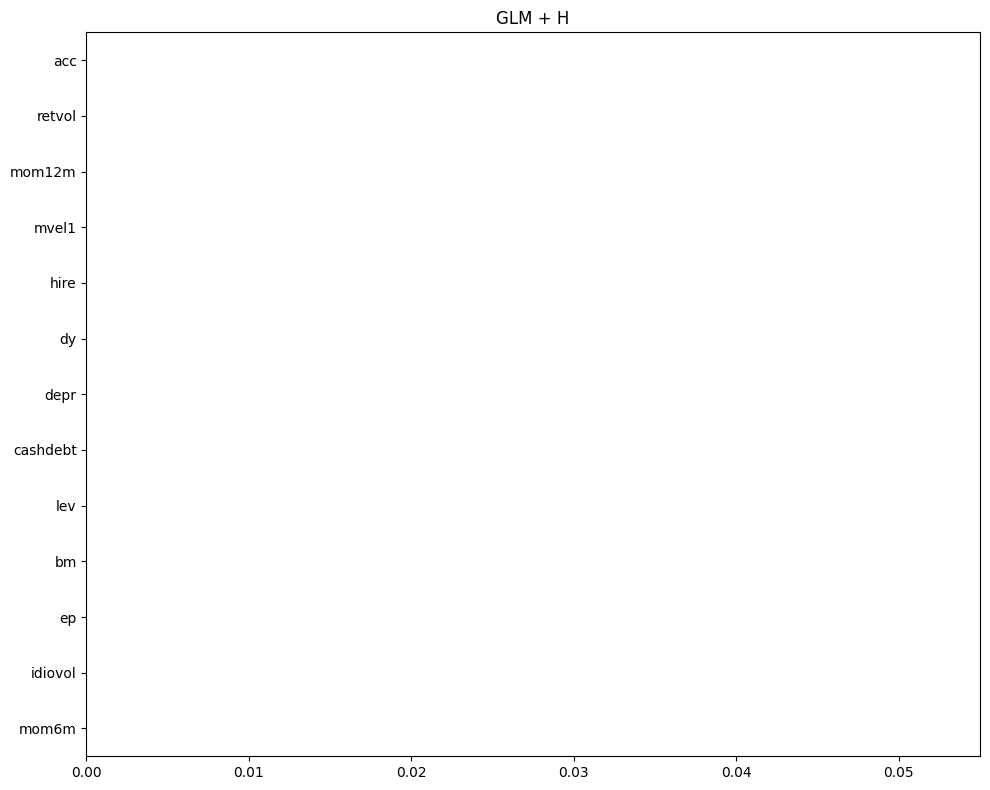

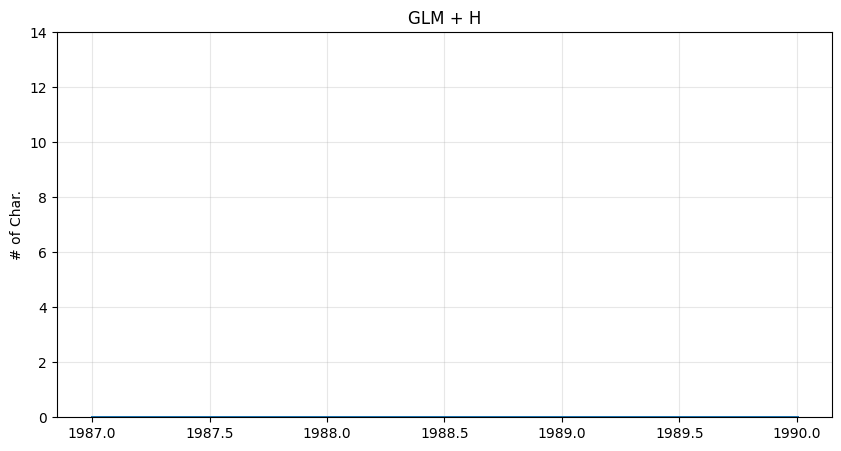

In [9]:
print("\nCalculating Variable Importance...")

vi_series = compute_vi_r2_reduction(
    final_model,
    X_test_spline_last,
    y_test_last,
    feature_cols
)

vi_pct = (vi_series / vi_series.sum()) * 100

plt.figure(figsize=(10, 8))
vi_pct.sort_values(ascending=False).head(20).sort_values().plot(kind='barh')
plt.xlim(left=0)
plt.title("GLM + H")
plt.tight_layout()
plt.show()

plot_model_selection_over_time(all_years, features_selected_count)

### 7. Monthly Performance

In [11]:
results_df = pl.DataFrame({
    "date": all_test_dates,
    "actual": all_actuals,
    "pred": all_preds,
    "me": all_test_me
})

summary = (
    results_df
    .with_columns(
        rank = pl.col("me").rank(descending=True).over("date")
    )
    .with_columns(
        group = (
            pl.when(pl.col("rank") <= 1000).then(pl.lit("Top1000"))
            .when(pl.col("rank") > (pl.col("rank").max().over("date") - 1000)).then(pl.lit("Bottom1000"))
            .otherwise(pl.lit("Middle"))
        )
    )
)

print("\n" + "="*35)
print(f"{'MONTHLY PERFORMANCE':^35}")
print("="*35)

for g in ["Full Sample", "Top1000", "Bottom1000"]:
    data = summary if g == "Full Sample" else summary.filter(pl.col("group") == g)

    print(f"{g:15} R2_oos: {r2_oos(
        data['actual'].to_numpy(),
        data['pred'].to_numpy()
    ):.4%}")

print("="*35)



        MONTHLY PERFORMANCE        
Full Sample     R2_oos: -0.3490%
Top1000         R2_oos: 0.7918%
Bottom1000      R2_oos: -0.9999%


### 8. Annual Performance

In [13]:
print("\n" + "="*45)
print(f"{'ANNUAL PERFORMANCE (TABLE 2)':^45}")
print("="*45)

df_annual = pd.DataFrame({
    'permno': all_test_permno,
    'year': pd.to_datetime(all_test_dates).year,   
    'actual': all_actuals,
    'pred': all_preds,
    'me': all_test_me
})

annual = (
    df_annual
    .groupby(['permno', 'year'])
    .agg({'actual': 'sum', 'pred': 'sum', 'me': 'first'})
    .reset_index()
)

annual['rank'] = annual.groupby('year')['me'].rank(ascending=False)
annual['max_rank'] = annual.groupby('year')['rank'].transform('max')

for label, mask in [
    ("Full Annual", annual['rank'] > 0),
    ("Top 1000", annual['rank'] <= 1000),
    ("Bottom 1000", annual['rank'] > annual['max_rank'] - 1000)
]:
    sub = annual[mask]

    print(f"{label:20} R2_oos: {r2_oos(
        sub['actual'].values,
        sub['pred'].values
    ):.4%}")

print("="*45)



        ANNUAL PERFORMANCE (TABLE 2)         
Full Annual          R2_oos: -4.0401%
Top 1000             R2_oos: -1.2453%
Bottom 1000          R2_oos: -0.8593%


### 9. Diebold Mariano Test

In [14]:
print("\nGenerating Monthly Error Series for DM Test...")

dm_export = pd.DataFrame({
    "date": all_test_dates,
    "sq_error": (np.array(all_actuals) - np.array(all_preds))**2
})

monthly_mse = (
    dm_export
    .groupby("date")["sq_error"]
    .mean()
    .reset_index()
)

monthly_mse.columns = ["date", "lasso_mse"]
monthly_mse.to_csv("lasso_dm_series.csv", index=False)

print("Saved 'lasso_dm_series.csv' for DM testing.")



Generating Monthly Error Series for DM Test...
Saved 'lasso_dm_series.csv' for DM testing.


### 10. Marginal Association Plots

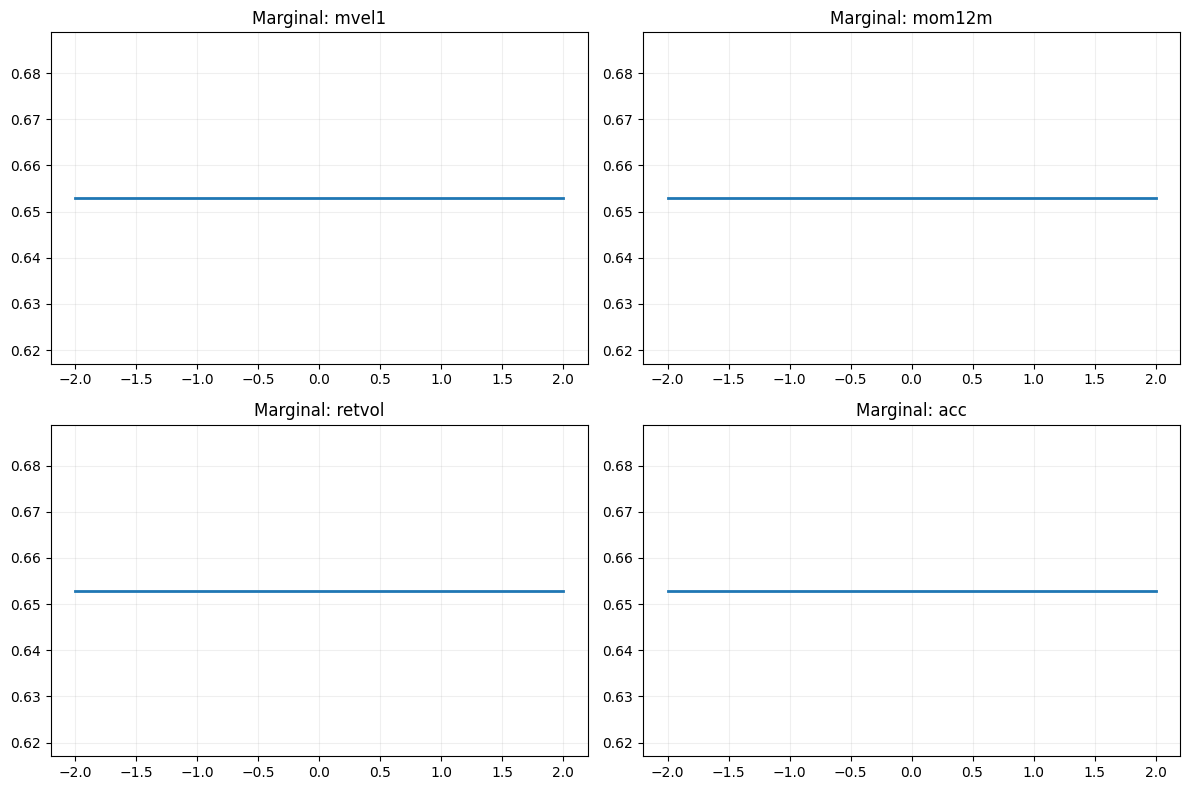

In [15]:
target_vars = ["mvel1", "mom12m", "retvol", "acc"]

plt.figure(figsize=(12, 8))

for i, var in enumerate([v for v in target_vars if v in feature_cols]):
    plt.subplot(2, 2, i + 1)

    xr = np.linspace(-2, 2, 100)
    Xm = np.zeros((100, len(feature_cols)), dtype=np.float32)  

    Xm[:, feature_cols.index(var)] = xr

    ym = final_model.predict(get_gkx_spline_k3(Xm)).flatten() * 100

    plt.plot(xr, ym, lw=2)
    plt.title(f"Marginal: {var}")
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 11. Save Stock-Level OOS Predictions

Save the full out-of-sample prediction panel with stock identifiers. This is the durable input for bottom-up portfolio replication and model comparisons.


In [ ]:
from pathlib import Path

# Mount Google Drive when running in Colab.
try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

PREDICTION_SOURCE = "glm_3"
SOURCE_NOTEBOOK = "Notebooks for Methodology/glm 3.ipynb"
SOURCE_PANEL = PATH
MODEL_NAME = "GLM_GroupLasso_Spline"

output_dir = Path("/content/drive/MyDrive/Replication Paper/Data/results") / PREDICTION_SOURCE
output_dir.mkdir(parents=True, exist_ok=True)

n_predictions = len(all_preds)
if "all_test_exchcd" not in globals() or len(all_test_exchcd) != n_predictions:
    all_test_exchcd = [np.nan] * n_predictions
if "all_test_best_lam" not in globals() or len(all_test_best_lam) != n_predictions:
    all_test_best_lam = [np.nan] * n_predictions
if "all_test_active_features" not in globals() or len(all_test_active_features) != n_predictions:
    all_test_active_features = [np.nan] * n_predictions

glm_oos_predictions = pd.DataFrame({
    "source_notebook": SOURCE_NOTEBOOK,
    "source_panel": SOURCE_PANEL,
    "prediction_source": PREDICTION_SOURCE,
    "prediction_scope": "stock_level_oos_with_ids_for_bottom_up_portfolios",
    "model": MODEL_NAME,
    "test_year": pd.to_datetime(all_test_dates).year.astype("int16"),
    "date": all_test_dates,
    "permno": all_test_permno,
    "exchcd": all_test_exchcd,
    "me": all_test_me,
    "ret_excess": all_actuals,
    "actual": all_actuals,
    "prediction": all_preds,
    "predicted": all_preds,
    "best_lambda": all_test_best_lam,
    "active_features": all_test_active_features,
})

glm_oos_predictions["date"] = pd.to_datetime(glm_oos_predictions["date"])
glm_oos_predictions = glm_oos_predictions.sort_values(["date", "permno"]).reset_index(drop=True)

prediction_path = output_dir / f"{PREDICTION_SOURCE}_stock_level_oos_predictions_with_ids.parquet"
manifest_path = output_dir / f"{PREDICTION_SOURCE}_prediction_manifest.csv"

glm_oos_predictions.to_parquet(prediction_path, index=False)

manifest = pd.DataFrame([{
    "prediction_source": PREDICTION_SOURCE,
    "source_notebook": SOURCE_NOTEBOOK,
    "source_panel": SOURCE_PANEL,
    "model": MODEL_NAME,
    "file_type": "stock_level_oos_predictions_with_ids",
    "path": str(prediction_path),
    "rows": len(glm_oos_predictions),
    "columns": ",".join(glm_oos_predictions.columns),
}])
manifest.to_csv(manifest_path, index=False)

print(f"Saved GLM stock-level OOS predictions: {prediction_path}")
print(f"Saved GLM prediction manifest: {manifest_path}")
print(f"Prediction panel shape: {glm_oos_predictions.shape}")
print(glm_oos_predictions[["model", "permno", "date", "ret_excess", "prediction", "me", "exchcd"]].head())
